In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

### Two networks interposed

- Layer 1: random network with 500 nodes and $p=0.05$. [Serves as more frequent contacts].
- Layer 2: random network with 500 nodes and $p=0.02$ (Less connectivity). [Serves as sporadic contacts].

Perform adaptive process for each network to reduce corresponding nodes. Adaptive parameters:

- Layer 1: T=14 days, $\nu=0.025$
- Layer 2: T=14 days, $\nu=0.0125$ (individuals are more sensitive).

The main difference in this example is that the adjacency matrix used to compute disease transition probabilities is the boolean sum of the two adjacency matrices for the two interposed networks.

In [63]:
dat_ = pd.read_csv('./Data/twonetworkexperiment.csv') #2layerexperiment.csv')
dat_

,day,s_mean,s_max,s_min,s_std,i_mean,i_max,i_min,i_std,r_mean,...,suscedgecount1_min,suscedgecount1_std,edgecount2_mean,edgecount2_max,edgecount2_min,edgecount2_std,suscedgecount2_mean,suscedgecount2_max,suscedgecount2_min,suscedgecount2_std
0,1,0.99744,0.998,0.994,0.001146,0.00248,0.006,0.0,0.001111,0.00008,...,0.999931,0.000010,0.999984,1.0,0.999599,0.000079,0.999996,1.0,0.999777,0.000032
1,2,0.99680,0.998,0.992,0.001666,0.00312,0.008,0.0,0.001674,0.00008,...,0.999861,0.000024,0.999960,1.0,0.999202,0.000146,0.999988,1.0,0.999705,0.000053
2,3,0.99568,0.998,0.988,0.002436,0.00416,0.012,0.0,0.002385,0.00016,...,0.999728,0.000042,0.999856,1.0,0.998797,0.000301,0.999936,1.0,0.999417,0.000140
3,4,0.99436,0.998,0.982,0.003492,0.00536,0.016,0.0,0.003439,0.00028,...,0.999727,0.000045,0.999744,1.0,0.998405,0.000411,0.999886,1.0,0.999338,0.000184
4,5,0.99280,0.998,0.980,0.004463,0.00672,0.018,0.0,0.004440,0.00048,...,0.999459,0.000091,0.999567,1.0,0.997208,0.000677,0.999808,1.0,0.998817,0.000296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,0.08116,0.998,0.000,0.273114,0.03928,0.068,0.0,0.014845,0.87956,...,0.987654,0.002632,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000
196,197,0.08116,0.998,0.000,0.273114,0.03836,0.066,0.0,0.014623,0.88048,...,0.987654,0.002632,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000
197,198,0.08116,0.998,0.000,0.273114,0.03768,0.064,0.0,0.014453,0.88116,...,0.987654,0.002632,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000
198,199,0.08116,0.998,0.000,0.273114,0.03680,0.062,0.0,0.014200,0.88204,...,0.987654,0.002632,1.000000,1.0,1.000000,0.000000,1.000000,1.0,1.000000,0.000000


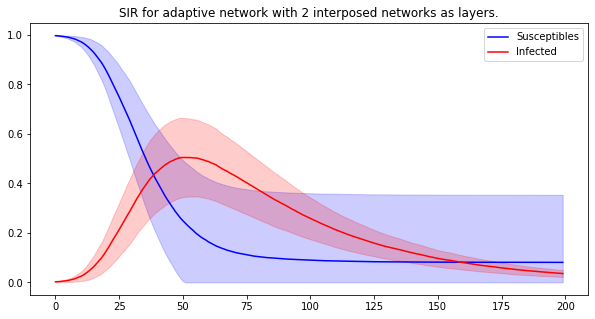

In [64]:
dat_['i_lower'] = dat_['i_mean'] - dat_['i_std']
dat_['i_upper'] = dat_['i_mean'] + dat_['i_std']
dat_['i_lower'] = dat_['i_lower'].apply(lambda x :max(x,0))

dat_['s_lower'] = dat_['s_mean'] - dat_['s_std']
dat_['s_upper'] = dat_['s_mean'] + dat_['s_std']
dat_['s_lower'] = dat_['s_lower'].apply(lambda x :max(x,0))

plt.figure(figsize=(10,5))
plt.plot(dat_['s_mean'], '-b', label="Susceptibles")
plt.fill_between(range(len(dat_['s_mean'])), 
                 dat_['s_lower'], dat_['s_upper'], alpha=0.2, color='b')

plt.plot(dat_['i_mean'], '-r', label="Infected")
plt.fill_between(range(len(dat_['i_mean'])), 
                 dat_['i_lower'], dat_['i_upper'], alpha=0.2, color='r')
plt.title("SIR for adaptive network with 2 interposed networks as layers.")
plt.legend(loc="upper right")
plt.show()

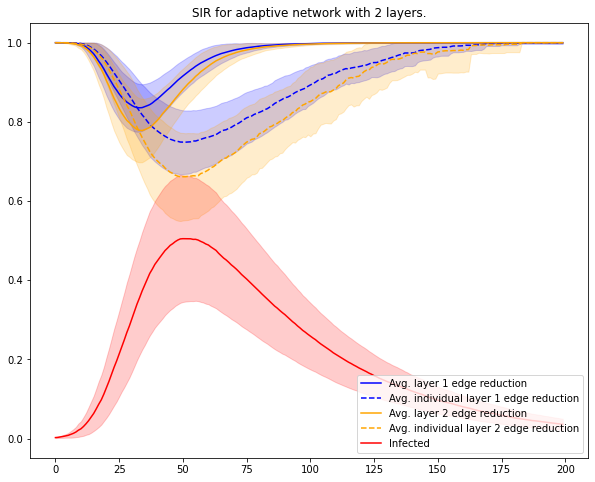

In [73]:
dat_['edgecount1_lower'] = dat_['edgecount1_mean'] - dat_['edgecount1_std']
dat_['edgecount1_upper'] = dat_['edgecount1_mean'] + dat_['edgecount1_std']
dat_['suscedgecount1_lower'] = dat_['suscedgecount1_mean'] - dat_['suscedgecount1_std']
dat_['suscedgecount1_upper'] = dat_['suscedgecount1_mean'] + dat_['suscedgecount1_std']

dat_['edgecount2_lower'] = dat_['edgecount2_mean'] - dat_['edgecount2_std']
dat_['edgecount2_upper'] = dat_['edgecount2_mean'] + dat_['edgecount2_std']
dat_['suscedgecount2_lower'] = dat_['suscedgecount2_mean'] - dat_['suscedgecount2_std']
dat_['suscedgecount2_upper'] = dat_['suscedgecount2_mean'] + dat_['suscedgecount2_std']

dat_['suscedgecount2_upper'] = dat_['suscedgecount2_upper'].apply(lambda x :min(x,1))
dat_['edgecount2_upper'] = dat_['edgecount2_upper'].apply(lambda x :min(x,1))
dat_['suscedgecount1_upper'] = dat_['suscedgecount1_upper'].apply(lambda x :min(x,1))
dat_['edgecount1_upper'] = dat_['edgecount1_upper'].apply(lambda x :min(x,1))

plt.figure(figsize=(10,8))

# Layer 1
plt.plot(dat_['edgecount1_mean'],'-b', label="Avg. layer 1 edge reduction")
plt.fill_between(range(len(dat_['edgecount1_mean'])), 
                 dat_['edgecount1_lower'], dat_['edgecount1_upper'], alpha=0.2, color='b')

plt.plot(dat_['suscedgecount1_mean'], linestyle='--', color='b', label="Avg. individual layer 1 edge reduction")
plt.fill_between(range(len(dat_['suscedgecount1_mean'])), 
                 dat_['suscedgecount1_lower'], dat_['suscedgecount1_upper'], alpha=0.2, color='b')

# Layer 2
plt.plot(dat_['edgecount2_mean'],'orange', label="Avg. layer 2 edge reduction")
plt.fill_between(range(len(dat_['edgecount2_mean'])), 
                 dat_['edgecount2_lower'], dat_['edgecount2_upper'], alpha=0.2, color='orange')

plt.plot(dat_['suscedgecount2_mean'], linestyle='--', color='orange', label="Avg. individual layer 2 edge reduction")
plt.fill_between(range(len(dat_['suscedgecount2_mean'])), 
                 dat_['suscedgecount2_lower'], dat_['suscedgecount2_upper'], alpha=0.2, color='orange')

plt.plot(dat_['i_mean'], '-r', label="Infected")
plt.fill_between(range(len(dat_['i_mean'])), 
                 dat_['i_lower'], dat_['i_upper'], alpha=0.2, color='r')

plt.title("SIR for adaptive network with 2 layers.")
plt.legend(loc="lower right")
plt.show()

In [75]:
# print(f"""
# mean1 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount1_mean']])} }};
# lower1 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount1_lower']])} }};
# upper1 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount1_upper']])} }};

# suscmean1 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount1_mean']])} }};
# susclower1 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount1_lower']])} }};
# suscupper1 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount1_upper']])} }};

# mean2 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount2_mean']])} }};
# lower2 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount2_lower']])} }};
# upper2 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount2_upper']])} }};

# suscmean2 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount2_mean']])} }};
# susclower2 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount2_lower']])} }};
# suscupper2 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount2_upper']])} }};

# imean2 = {{ {','.join([str(round(x,4)) for x in dat_['i_mean']])} }};
# ilower2 = {{ {','.join([str(round(x,4)) for x in dat_['i_lower']])} }};
# iupper2 = {{ {','.join([str(round(x,4)) for x in dat_['i_upper']])} }};

# """)

We can see that contact adaptation occurs more drastically for the outer sporadic layer.

### One network for layer 1 contacts and layer 2 contacts performed sporadically within the same network

We build an underlying network. The layer 1 contacts are to be pooled from the neighbors of this network using the adaptive decision process. The layer 2 contacts are pooled from the rest of the network nodes sporadically, also using the adaptive algorithm to decide the optimal number of nodes to select for this network. So, each day, susceptible nodes have contacts with a sample of their original neighbors and a sample of other neighbors chosen randomly from the rest of the population, but the amount to choose is computed with the adaptive framework.

In [8]:
dat_ = pd.read_csv('./Data/sporadicexperiment.csv') # layerexperiment.csv')
print(dat_.columns)

dat_['i_lower'] = dat_['i_mean'] - dat_['i_std']
dat_['i_upper'] = dat_['i_mean'] + dat_['i_std']
dat_['i_lower'] = dat_['i_lower'].apply(lambda x :max(x,0))

dat_['edgecount_lower'] = dat_['edgecount_mean'] - dat_['edgecount_std']
dat_['edgecount_upper'] = dat_['edgecount_mean'] + dat_['edgecount_std']
dat_['edgecount_upper'] = dat_['edgecount_upper'].apply(lambda x :min(x,1))

dat_['suscedgecount_lower'] = dat_['suscedgecount_mean'] - dat_['suscedgecount_std']
dat_['suscedgecount_upper'] = dat_['suscedgecount_mean'] + dat_['suscedgecount_std']
dat_['suscedgecount_upper'] = dat_['suscedgecount_upper'].apply(lambda x :min(x,1))

dat_['edgecount1_lower'] = dat_['edgecount1_mean'] - dat_['edgecount1_std']
dat_['edgecount1_upper'] = dat_['edgecount1_mean'] + dat_['edgecount1_std']
dat_['edgecount1_upper'] = dat_['edgecount1_upper'].apply(lambda x :min(x,1))

dat_['suscedgecount1_lower'] = dat_['suscedgecount1_mean'] - dat_['suscedgecount1_std']
dat_['suscedgecount1_upper'] = dat_['suscedgecount1_mean'] + dat_['suscedgecount1_std']
dat_['suscedgecount1_upper'] = dat_['suscedgecount1_upper'].apply(lambda x :min(x,1))

dat_['edgecount2_lower'] = dat_['edgecount2_mean'] - dat_['edgecount2_std']
dat_['edgecount2_upper'] = dat_['edgecount2_mean'] + dat_['edgecount2_std']
dat_['edgecount2_upper'] = dat_['edgecount2_upper'].apply(lambda x :min(x,1))

dat_['suscedgecount2_lower'] = dat_['suscedgecount2_mean'] - dat_['suscedgecount2_std']
dat_['suscedgecount2_upper'] = dat_['suscedgecount2_mean'] + dat_['suscedgecount2_std']
dat_['suscedgecount2_upper'] = dat_['suscedgecount2_upper'].apply(lambda x :min(x,1))

dat_

Index(['day', 's_mean', 's_max', 's_min', 's_std', 'i_mean', 'i_max', 'i_min',
       'i_std', 'r_mean', 'r_max', 'r_min', 'r_std', 'edgecount_mean',
       'edgecount_max', 'edgecount_min', 'edgecount_std', 'suscedgecount_mean',
       'suscedgecount_max', 'suscedgecount_min', 'suscedgecount_std',
       'edgecount1_mean', 'edgecount1_max', 'edgecount1_min', 'edgecount1_std',
       'suscedgecount1_mean', 'suscedgecount1_max', 'suscedgecount1_min',
       'suscedgecount1_std', 'edgecount2_mean', 'edgecount2_max',
       'edgecount2_min', 'edgecount2_std', 'suscedgecount2_mean',
       'suscedgecount2_max', 'suscedgecount2_min', 'suscedgecount2_std'],
      dtype='object')


,day,s_mean,s_max,s_min,s_std,i_mean,i_max,i_min,i_std,r_mean,...,suscedgecount_lower,suscedgecount_upper,edgecount1_lower,edgecount1_upper,suscedgecount1_lower,suscedgecount1_upper,edgecount2_lower,edgecount2_upper,suscedgecount2_lower,suscedgecount2_upper
0,1,0.99664,0.998,0.992,0.001638,0.00328,0.008,0.002,0.001604,0.00008,...,0.982504,0.995489,0.999826,1.0,0.999916,1.0,0.983602,1.000000,0.961857,0.989942
1,2,0.99524,0.998,0.986,0.002882,0.00460,0.014,0.000,0.002921,0.00016,...,0.973507,0.994499,0.999444,1.0,0.999761,1.0,0.961146,1.000000,0.942709,0.987278
2,3,0.99304,0.998,0.980,0.004734,0.00668,0.018,0.000,0.004653,0.00028,...,0.963376,0.992684,0.998563,1.0,0.999314,1.0,0.934751,0.997187,0.920128,0.983563
3,4,0.99000,0.998,0.972,0.006676,0.00948,0.028,0.000,0.006710,0.00052,...,0.951422,0.990623,0.997372,1.0,0.998705,1.0,0.905376,0.991227,0.894887,0.979161
4,5,0.98616,0.998,0.956,0.010011,0.01284,0.040,0.000,0.009485,0.00100,...,0.933060,0.987334,0.995146,1.0,0.997636,1.0,0.860804,0.983312,0.855635,0.972369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,0.04100,0.998,0.000,0.197335,0.00520,0.016,0.000,0.003614,0.95380,...,0.952001,1.000000,1.000000,1.0,1.000000,1.0,0.970308,0.995136,0.899203,1.000000
196,197,0.04100,0.998,0.000,0.197335,0.00508,0.014,0.000,0.003410,0.95392,...,0.836288,1.000000,1.000000,1.0,1.000000,1.0,0.971269,0.994237,0.699952,1.000000
197,198,0.04100,0.998,0.000,0.197335,0.00484,0.014,0.000,0.003184,0.95416,...,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.972398,0.995172,1.000000,1.000000
198,199,0.04100,0.998,0.000,0.197335,0.00464,0.012,0.000,0.002981,0.95436,...,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.972805,0.994773,1.000000,1.000000


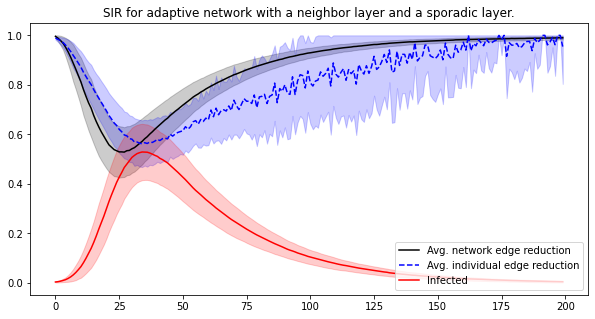

In [9]:
plt.figure(figsize=(10,5))

plt.plot(dat_['edgecount_mean'],'-k', label="Avg. network edge reduction")
plt.fill_between(range(len(dat_['edgecount_mean'])), 
                 dat_['edgecount_lower'], dat_['edgecount_upper'], alpha=0.2, color='k')

plt.plot(dat_['suscedgecount_mean'], linestyle='--', color='b', label="Avg. individual edge reduction")
plt.fill_between(range(len(dat_['suscedgecount_mean'])),
                 dat_['suscedgecount_lower'], dat_['suscedgecount_upper'], alpha=0.2, color='b')

plt.plot(dat_['i_mean'], '-r', label="Infected")
plt.fill_between(range(len(dat_['i_mean'])), 
                 dat_['i_lower'], dat_['i_upper'], alpha=0.2, color='r')

plt.title("SIR for adaptive network with a neighbor layer and a sporadic layer.")
plt.legend(loc="lower right")
plt.show()

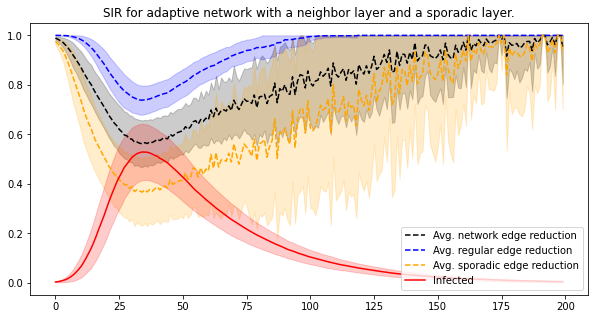

In [20]:
plt.figure(figsize=(10,5))

plt.plot(dat_['suscedgecount_mean'],'-k', linestyle='dashed', label="Avg. network edge reduction")
plt.fill_between(range(len(dat_['suscedgecount_mean'])), 
                 dat_['suscedgecount_lower'], dat_['suscedgecount_upper'], alpha=0.2, color='k')

plt.plot(dat_['suscedgecount1_mean'],'-b', linestyle='dashed', label="Avg. regular edge reduction")
plt.fill_between(range(len(dat_['suscedgecount1_mean'])), 
                 dat_['suscedgecount1_lower'], dat_['suscedgecount1_upper'], alpha=0.2, color='b')

plt.plot(dat_['suscedgecount2_mean'],'orange', linestyle='dashed', label="Avg. sporadic edge reduction")
plt.fill_between(range(len(dat_['suscedgecount2_mean'])), 
                 dat_['suscedgecount2_lower'], dat_['suscedgecount2_upper'], alpha=0.2, color='orange')

plt.plot(dat_['i_mean'], '-r', label="Infected")
plt.fill_between(range(len(dat_['i_mean'])), 
                 dat_['i_lower'], dat_['i_upper'], alpha=0.2, color='r')

plt.title("SIR for adaptive network with a neighbor layer and a sporadic layer.")
plt.legend(loc="lower right")
plt.show()

In [24]:
# print(f"""

# suscmean = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount_mean']])} }};
# susclower = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount_lower']])} }};
# suscupper = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount_upper']])} }};

# suscmean1 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount1_mean']])} }};
# susclower1 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount1_lower']])} }};
# suscupper1 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount1_upper']])} }};

# suscmean2 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount2_mean']])} }};
# susclower2 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount2_lower']])} }};
# suscupper2 = {{ {','.join([str(round(x,4)) for x in dat_['suscedgecount2_upper']])} }};

# imean2 = {{ {','.join([str(round(x,4)) for x in dat_['i_mean']])} }};
# ilower2 = {{ {','.join([str(round(x,4)) for x in dat_['i_lower']])} }};
# iupper2 = {{ {','.join([str(round(x,4)) for x in dat_['i_upper']])} }};

# """)

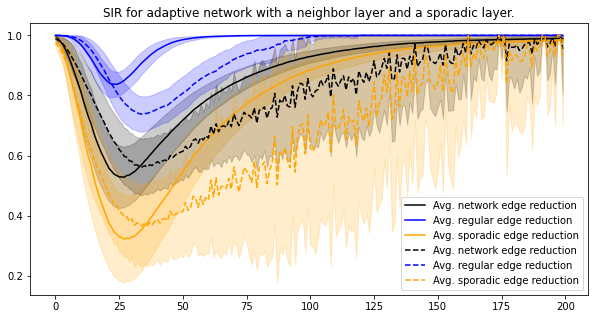

In [23]:
plt.figure(figsize=(10,5))

plt.plot(dat_['edgecount_mean'],'-k', label="Avg. network edge reduction")
plt.fill_between(range(len(dat_['edgecount_mean'])), 
                 dat_['edgecount_lower'], dat_['edgecount_upper'], alpha=0.2, color='k')

plt.plot(dat_['edgecount1_mean'],'-b', label="Avg. regular edge reduction")
plt.fill_between(range(len(dat_['edgecount1_mean'])), 
                 dat_['edgecount1_lower'], dat_['edgecount1_upper'], alpha=0.2, color='b')

plt.plot(dat_['edgecount2_mean'],'orange', label="Avg. sporadic edge reduction")
plt.fill_between(range(len(dat_['edgecount2_mean'])), 
                 dat_['edgecount2_lower'], dat_['edgecount2_upper'], alpha=0.2, color='orange')

plt.plot(dat_['suscedgecount_mean'],'-k', linestyle='dashed', label="Avg. network edge reduction")
plt.fill_between(range(len(dat_['suscedgecount_mean'])), 
                 dat_['suscedgecount_lower'], dat_['suscedgecount_upper'], alpha=0.2, color='k')

plt.plot(dat_['suscedgecount1_mean'],'-b', linestyle='dashed', label="Avg. regular edge reduction")
plt.fill_between(range(len(dat_['suscedgecount1_mean'])), 
                 dat_['suscedgecount1_lower'], dat_['suscedgecount1_upper'], alpha=0.2, color='b')

plt.plot(dat_['suscedgecount2_mean'],'orange', linestyle='dashed', label="Avg. sporadic edge reduction")
plt.fill_between(range(len(dat_['suscedgecount2_mean'])), 
                 dat_['suscedgecount2_lower'], dat_['suscedgecount2_upper'], alpha=0.2, color='orange')

plt.title("SIR for adaptive network with a neighbor layer and a sporadic layer.")
plt.legend(loc="lower right")
plt.show()

In [25]:
print(f"""

mean = {{ {','.join([str(round(x,4)) for x in dat_['edgecount_mean']])} }};
lower = {{ {','.join([str(round(x,4)) for x in dat_['edgecount_lower']])} }};
upper = {{ {','.join([str(round(x,4)) for x in dat_['edgecount_upper']])} }};

mean1 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount1_mean']])} }};
lower1 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount1_lower']])} }};
upper1 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount1_upper']])} }};

mean2 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount2_mean']])} }};
lower2 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount2_lower']])} }};
upper2 = {{ {','.join([str(round(x,4)) for x in dat_['edgecount2_upper']])} }};

""")



mean = { 0.9962,0.9886,0.9791,0.9681,0.9517,0.9327,0.9112,0.887,0.8627,0.8369,0.8118,0.7806,0.7532,0.7272,0.7059,0.6767,0.6521,0.6301,0.6099,0.5918,0.5744,0.5575,0.5477,0.5384,0.5335,0.529,0.5291,0.5282,0.5338,0.535,0.5415,0.5463,0.5545,0.5633,0.5715,0.582,0.5903,0.601,0.6102,0.6206,0.6298,0.6396,0.6482,0.6578,0.6655,0.676,0.6848,0.6934,0.7011,0.7097,0.7181,0.7262,0.7339,0.7419,0.7505,0.7572,0.7633,0.7707,0.7763,0.7833,0.7892,0.7949,0.8001,0.8059,0.8111,0.8158,0.821,0.8261,0.8311,0.8356,0.8407,0.844,0.8482,0.8524,0.8567,0.8608,0.8644,0.8684,0.8717,0.8753,0.8784,0.8817,0.8846,0.8877,0.8909,0.8938,0.8966,0.8992,0.9023,0.9042,0.9077,0.9103,0.913,0.9148,0.917,0.9195,0.9222,0.9237,0.9261,0.9282,0.9295,0.9314,0.9331,0.9349,0.9369,0.9383,0.9397,0.941,0.9425,0.9445,0.9459,0.9474,0.9486,0.9498,0.9506,0.9518,0.9529,0.9547,0.9553,0.9566,0.9573,0.9586,0.9595,0.9608,0.962,0.963,0.9632,0.9641,0.9656,0.9662,0.9669,0.9681,0.9688,0.9693,0.97,0.9705,0.9714,0.9722,0.9729,0.9737,0.9736,0.9743,0.9748,0.9

Which experiment is *better*?

In [1]:
import igraph
from network2tikz import plot

net = igraph.Graph([(0,1), (0,2), (2,3), (3,4), (4,2), (2,5), (5,0), (6,3),
                    (5,6), (6,6)],directed=True)

ModuleNotFoundError: No module named 'igraph'